# 🏠 Predicting Median House Values in California Districts

In [439]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
def data_load():  
    # Load California Housing dataset
    housing = fetch_california_housing(as_frame=True)
    dataframe = housing.frame
    
    # Rename columns for better readability
    dataframe.columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 
                  'Population', 'AveOccup', 'Latitude', 'Longitude', 
                  'MedHouseVal']

    return dataframe

In [441]:
def split_data(dataframe):    
    # Split Data into training and test (70% and 30%)
    train, test = train_test_split(dataframe, test_size = 0.3, random_state=1)
    
    # Training Data
    # All columns except the last one (MedHouseVal) are features
    train_x = train.iloc[:, :-1]
    train_y = train.iloc[:, -1:]
    
    # Testing Data
    test_x = test.iloc[:, :-1]
    test_y = test.iloc[:, -1:]
    
    # Converting Training and Test Data to numpy array
    train_x = np.asarray(train_x)
    train_y = np.asarray(train_y)
    test_x = np.asarray(test_x)
    test_y = np.asarray(test_y)
    
    scaler = StandardScaler()
    train_x = scaler.fit_transform(train_x)
    test_x = scaler.transform(test_x)

    # Return transposed arrays so that features are rows and data samples are columns
    return train_x.T, train_y.T, test_x.T, test_y.T

In [442]:
def initialize_weights_and_bias(num_of_features):
    weights = np.zeros((num_of_features, 1))
    bias = 0

    return weights, bias

In [443]:
def compute_gradients_and_cost(X, Y, weights, bias):    
    num_samples = X.shape[1]

    # Forward propagation: compute predictions and cost
    predictions = np.dot(weights.T, X) + bias
    errors = predictions - Y
    cost = (1 / (2 * num_samples)) * np.sum(errors ** 2)

    # Backward propagation: compute gradients
    dW = (1 / num_samples) * np.dot(X, errors.T)
    db = (1 / num_samples) * np.sum(errors)

    gradients = {"dw": dW, "db": db}
    return gradients, cost

In [444]:
def gradient_descent(X, Y, weights, bias, num_of_iterations, learning_rate):
    cost_history = []
    previous_cost = float('inf')
    
    for i in range(num_of_iterations):        
        gradients, cost = compute_gradients_and_cost(X, Y, weights, bias)

        dW = gradients['dw']
        db = gradients['db']

        # Update parameters
        weights = weights - (learning_rate * dW)
        bias = bias - (learning_rate * db)

        # Convergence check
        if abs(cost - previous_cost) < 1e-8:
            break

        # Store cost every 100 iterations
        if i % 100 == 0:
            cost_history.append(cost)

        # Print cost every 1000 iterations
        if i % 1000 == 0:
            print(f"Cost after {i} iterations: {cost:.6f}")

        previous_cost = cost

    parameters = {'weights': weights, 'bias': bias}
    return parameters, cost_history

In [445]:
def predict(X, weights, bias):
    
    return np.dot(weights.T, X) + bias

In [446]:
def evaluate_performance(train_y, prediction_train, test_y, prediction_test):   
    train_mae = mean_absolute_error(train_y.T, prediction_train.T)
    train_rmse = np.sqrt(mean_squared_error(train_y.T, prediction_train.T))
    train_r2 = r2_score(train_y.T, prediction_train.T)
    
    test_mae = mean_absolute_error(test_y.T, prediction_test.T)
    test_rmse = np.sqrt(mean_squared_error(test_y.T, prediction_test.T))
    test_r2 = r2_score(test_y.T, prediction_test.T)
    
    print("\n" + "="*50)
    print("TRAINING SET PERFORMANCE:")
    print("="*50)
    print(f"Mean Absolute Error (MAE): {train_mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {train_rmse:.4f}")
    print(f"R² Score: {train_r2:.4f}")
    
    print("\n" + "="*50)
    print("TEST SET PERFORMANCE:")
    print("="*50)
    print(f"Mean Absolute Error (MAE): {test_mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {test_rmse:.4f}")
    print(f"R² Score: {test_r2:.4f}")

In [447]:
def train_linear_regression_model(X, Y, num_of_iterations, learning_rate):
    num_features = X.shape[0]
    weights, bias = initialize_weights_and_bias(num_features)

    parameters, cost_history = gradient_descent(X, Y, weights, bias, num_of_iterations, learning_rate)

    return {
        'weights': parameters['weights'],
        'bias': parameters['bias'],
        'cost_history': cost_history
    }

## Multiple Linear Regression: Train, Predict, and Evaluate

Cost after 0 iterations: 2.825275
Cost after 1000 iterations: 0.275866
Cost after 2000 iterations: 0.264629
Cost after 3000 iterations: 0.262086
Cost after 4000 iterations: 0.261463
Cost after 5000 iterations: 0.261293
Cost after 6000 iterations: 0.261241
Cost after 7000 iterations: 0.261223

TRAINING SET PERFORMANCE:
Mean Absolute Error (MAE): 0.5306
Root Mean Squared Error (RMSE): 0.7228
R² Score: 0.6097

TEST SET PERFORMANCE:
Mean Absolute Error (MAE): 0.5350
Root Mean Squared Error (RMSE): 0.7277
R² Score: 0.5972


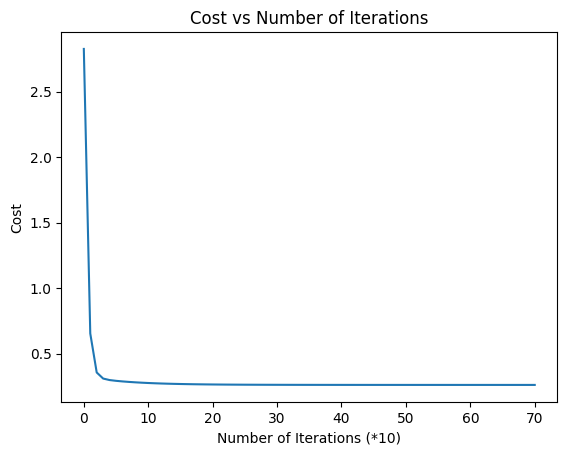

In [448]:
# Step 1: Load the dataset
dataframe = data_load()

# Step 2: Split dataset into training and testing set
train_x, train_y, test_x, test_y = split_data(dataframe)

# Step 3: Set hyperparameters
num_of_iterations = 150000  # Number of iterations for gradient descent
learning_rate = 0.01        # Learning rate for gradient descent

# Step 4: Train the linear regression model
result = train_linear_regression_model(train_x, train_y, num_of_iterations, learning_rate)

# Extract trained weights, bias, and cost history
weights = result['weights']
bias = result['bias']
cost_history = result['cost_history']

# Step 5: Plot cost function over iterations to check convergence
plt.plot(cost_history)
plt.title("Cost vs Number of Iterations")
plt.xlabel("Number of Iterations (*10)")
plt.ylabel("Cost")

# Step 6: Make predictions on training and test sets
prediction_train = predict(train_x, weights, bias)
prediction_test = predict(test_x, weights, bias)

# Step 7: Evaluate model performance on training and test set
evaluate_performance(train_y, prediction_train, test_y, prediction_test)